## Poin-poin Assignment
0. Import Dataset pilih salah satu :
- https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
- https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
- https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset
1. Jawablah poin-poin assignment yang tertera

In [1]:
# load pandas untuk data wrangling
import pandas as pd
# load numpy untuk manipulasi vektor
import numpy as np
# load matplotlib untuk visualisasi data
import matplotlib.pyplot as plt
# load seaborn untuk visualisasi data
import seaborn as sns

# load metrics object dari sklearn
from sklearn import metrics
# load train-test data splitter
from sklearn.model_selection import train_test_split
# Import Decision Tree classifier (DT)
from sklearn.tree import DecisionTreeClassifier
# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# load SVM classifier model
from sklearn.svm import SVC
# load KNN classifier model
from sklearn.neighbors import KNeighborsClassifier

#import for metrics
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Bimbing Bootcamp/Day Extra Class 8 - Churn Anylisis/Assignment Day Extra Class 8 - Churn Anylisis/customer_churn_dataset-testing-master.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (64374, 12)

First 5 rows:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
print("Data Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay    

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [5]:
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Churn Percentage:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


## Exploratory Data Analysis
- Lakukan analisa pada EDA menggunakan visualisasi di tiap variabel :
1. Kategorikal vs Churn Label
2. Numerik vs Churn Label
3. Anda wajib menuliskan insight, sebagai langkah untuk pencegahan churn dalam strategi marketing

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['Gender', 'Subscription Type', 'Contract Length']

Numerical Columns: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


/tmp/ipython-input-1208034283.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[1,1], palette=['#2ecc71', '#e74c3c'])


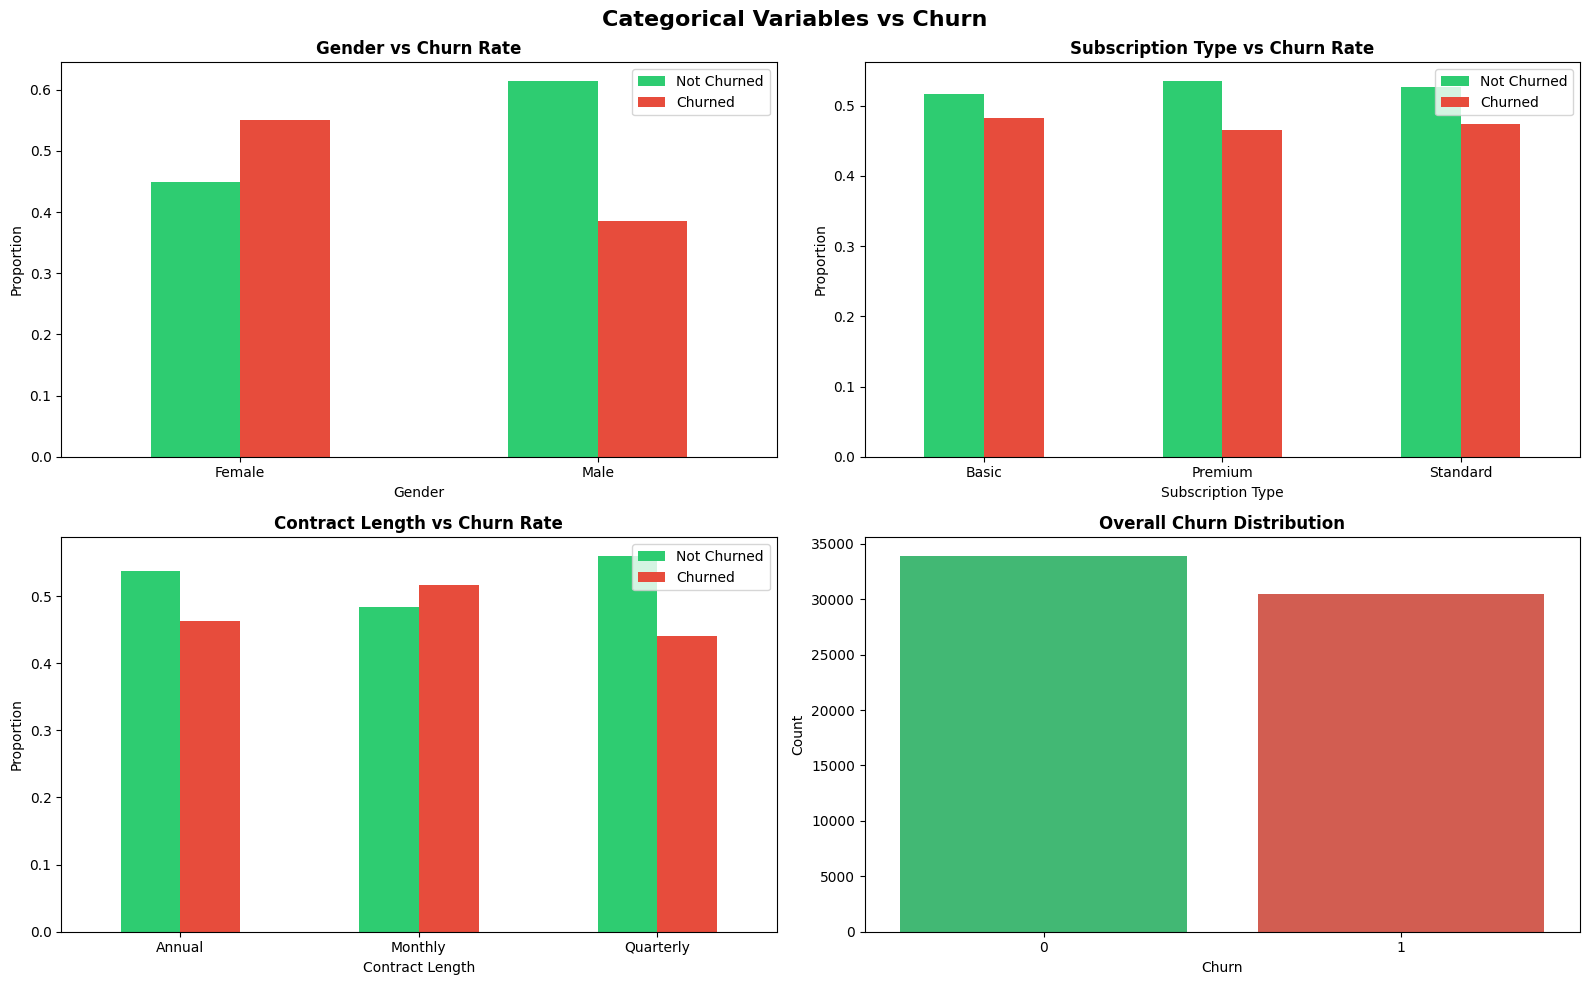

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Categorical Variables vs Churn', fontsize=16, fontweight='bold')

pd.crosstab(df['Gender'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Gender vs Churn Rate', fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Proportion')
axes[0,0].legend(['Not Churned', 'Churned'])
axes[0,0].tick_params(axis='x', rotation=0)

pd.crosstab(df['Subscription Type'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Subscription Type vs Churn Rate', fontweight='bold')
axes[0,1].set_xlabel('Subscription Type')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend(['Not Churned', 'Churned'])
axes[0,1].tick_params(axis='x', rotation=0)

pd.crosstab(df['Contract Length'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[1,0], color=['#2ecc71', '#e74c3c'])
axes[1,0].set_title('Contract Length vs Churn Rate', fontweight='bold')
axes[1,0].set_xlabel('Contract Length')
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(['Not Churned', 'Churned'])
axes[1,0].tick_params(axis='x', rotation=0)

sns.countplot(data=df, x='Churn', ax=axes[1,1], palette=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Overall Churn Distribution', fontweight='bold')
axes[1,1].set_xlabel('Churn')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
print("=" * 80)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 80)

for col in categorical_cols:
    print(f"\n{col.upper()} vs CHURN:")
    print("-" * 60)
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(crosstab.round(2))
    print()

CATEGORICAL VARIABLES ANALYSIS

GENDER vs CHURN:
------------------------------------------------------------
Churn       0      1
Gender              
Female  44.95  55.05
Male    61.42  38.58


SUBSCRIPTION TYPE vs CHURN:
------------------------------------------------------------
Churn                  0      1
Subscription Type              
Basic              51.72  48.28
Premium            53.50  46.50
Standard           52.67  47.33


CONTRACT LENGTH vs CHURN:
------------------------------------------------------------
Churn                0      1
Contract Length              
Annual           53.78  46.22
Monthly          48.39  51.61
Quarterly        55.95  44.05



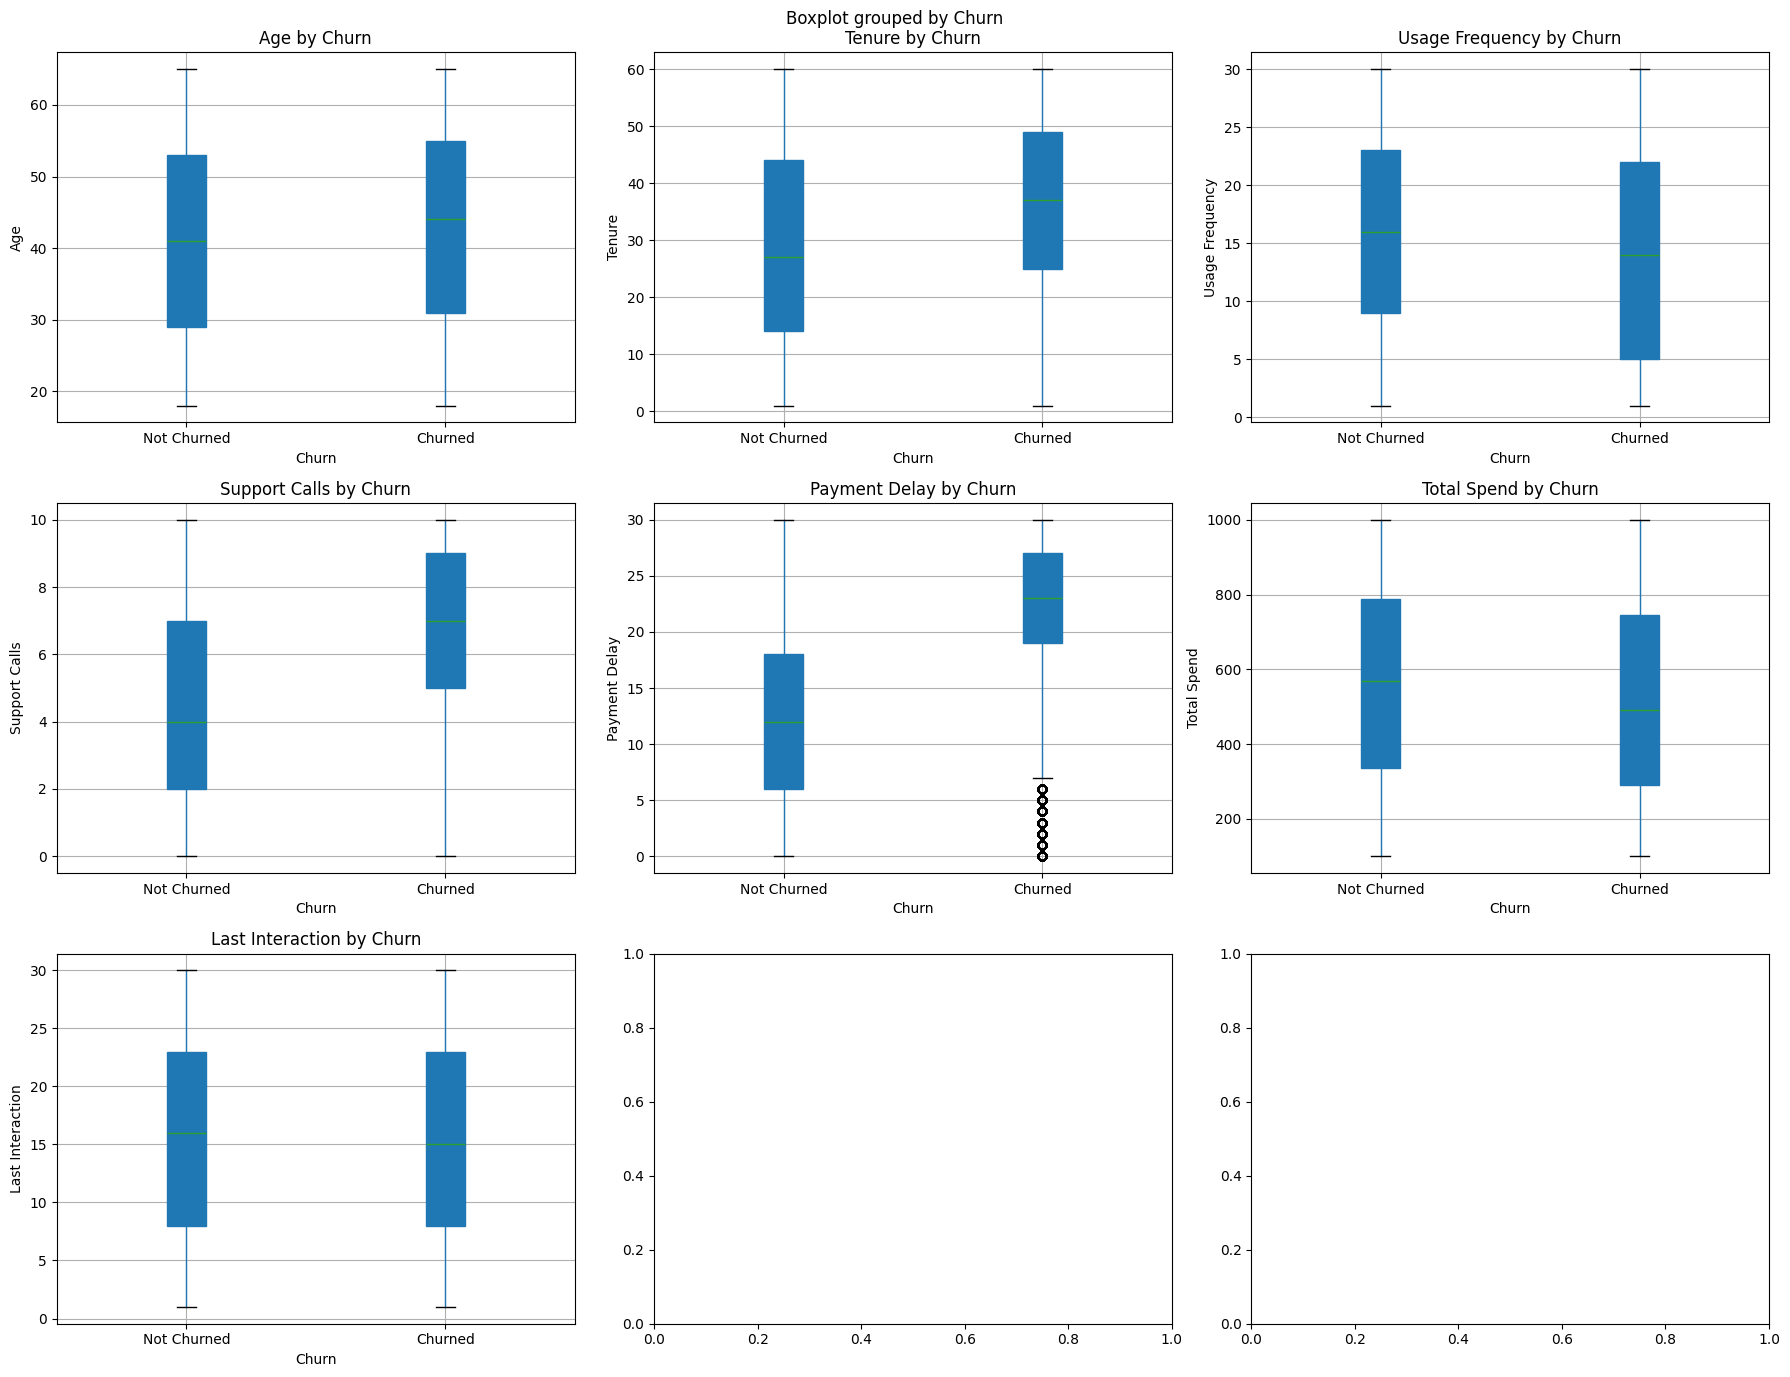

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Numerical Variables Distribution by Churn', fontsize=16, fontweight='bold')

num_cols_plot = numerical_cols[:9]

for idx, col in enumerate(num_cols_plot):
    row = idx // 3
    col_idx = idx % 3

    df.boxplot(column=col, by='Churn', ax=axes[row, col_idx], patch_artist=True)
    axes[row, col_idx].set_title(f'{col} by Churn')
    axes[row, col_idx].set_xlabel('Churn')
    axes[row, col_idx].set_ylabel(col)
    plt.sca(axes[row, col_idx])
    plt.xticks([1, 2], ['Not Churned', 'Churned'])

plt.tight_layout()
plt.show()

In [10]:
print("=" * 80)
print("NUMERICAL VARIABLES STATISTICS BY CHURN")
print("=" * 80)

for col in numerical_cols:
    print(f"\n{col.upper()}:")
    print("-" * 60)
    stats = df.groupby('Churn')[col].describe()[['mean', 'std', 'min', 'max']]
    print(stats.round(2))
    print()

NUMERICAL VARIABLES STATISTICS BY CHURN

AGE:
------------------------------------------------------------
        mean    std   min   max
Churn                          
0      41.13  13.75  18.0  65.0
1      42.90  14.06  18.0  65.0


TENURE:
------------------------------------------------------------
        mean    std  min   max
Churn                         
0      28.83  17.44  1.0  60.0
1      35.52  15.99  1.0  60.0


USAGE FREQUENCY:
------------------------------------------------------------
        mean   std  min   max
Churn                        
0      16.04  8.40  1.0  30.0
1      14.01  9.13  1.0  30.0


SUPPORT CALLS:
------------------------------------------------------------
       mean   std  min   max
Churn                       
0       4.5  3.17  0.0  10.0
1       6.4  2.72  0.0  10.0


PAYMENT DELAY:
------------------------------------------------------------
        mean   std  min   max
Churn                        
0      12.45  8.31  0.0  30.0
1      2

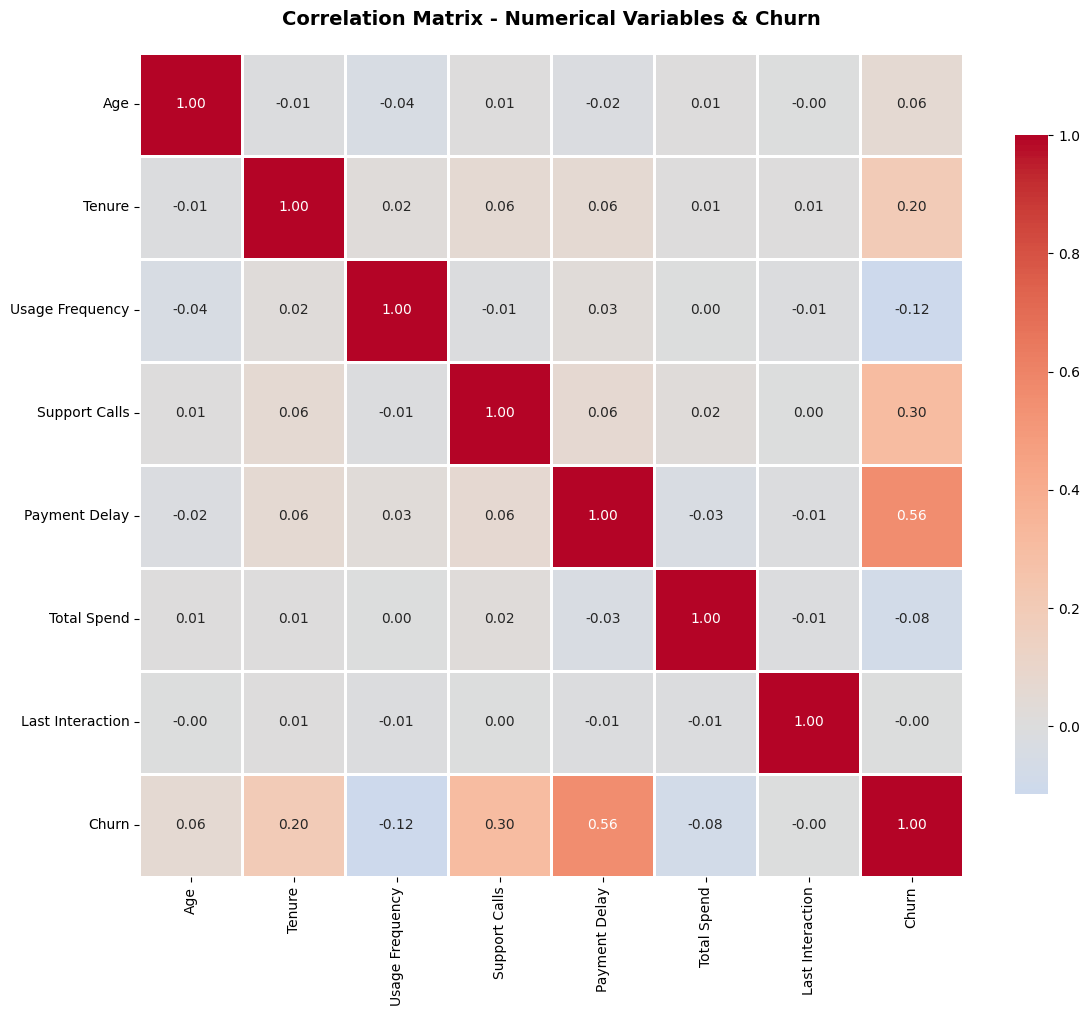


Correlation with Churn (sorted by absolute value):
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Usage Frequency    -0.115098
Total Spend        -0.078867
Age                 0.063457
Last Interaction   -0.002818
Name: Churn, dtype: float64


In [11]:
plt.figure(figsize=(12, 10))
correlation = df[numerical_cols + ['Churn']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Variables & Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelation with Churn (sorted by absolute value):")
print("=" * 60)
churn_corr = correlation['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr)

## Assignment Feature Engineering
1. Perhatikan splitting
2. Serta beri alasan anda dalam melakukan proses feature engineering di setiap prosesnya

In [12]:
df_model = df.drop('CustomerID', axis=1)

print("Dataset shape after dropping CustomerID:", df_model.shape)
print("\nColumns in modeling dataset:")
print(df_model.columns.tolist())

Dataset shape after dropping CustomerID: (64374, 11)

Columns in modeling dataset:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [13]:
df_encoded = pd.get_dummies(df_model, columns=['Gender', 'Subscription Type', 'Contract Length'],
                            drop_first=True, dtype=int)

print("Shape after encoding:", df_encoded.shape)
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

df_encoded.head()

Shape after encoding: (64374, 13)

Columns after encoding:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,0,1,1,0
2,47,27,10,2,29,757,21,0,1,1,0,0,0
3,35,9,12,5,17,232,18,0,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,0,1,0,0


**Alasan Encoding:**
- Machine learning algorithms membutuhkan input numerik
- Menggunakan One-Hot Encoding untuk nominal variables (Gender, Subscription Type, Contract Length)
- One-Hot Encoding dipilih karena tidak ada ordinal relationship antar kategori

In [14]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nChurn distribution in train set:")
print(y_train.value_counts(normalize=True))
print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set shape: (51499, 12)
Test set shape: (12875, 12)

Churn distribution in train set:
Churn
0    0.526321
1    0.473679
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    0.526291
1    0.473709
Name: proportion, dtype: float64


**Alasan Splitting:**
- Ratio 80:20 (train:test) adalah standar yang baik untuk dataset berukuran medium-large
- Stratify berdasarkan target variable (Churn) untuk memastikan proporsi kelas sama di train dan test set
- Random_state untuk reproducibility
- Splitting SEBELUM feature engineering lainnya untuk menghindari data leakage

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Training data after scaling:")
print(X_train_scaled.describe())

Training data after scaling:
                Age        Tenure  Usage Frequency  Support Calls  \
count  5.149900e+04  5.149900e+04     5.149900e+04   5.149900e+04   
mean  -1.340399e-16 -5.022186e-17     7.229740e-17   1.327292e-16   
std    1.000010e+00  1.000010e+00     1.000010e+00   1.000010e+00   
min   -1.724437e+00 -1.815041e+00    -1.595070e+00  -1.734658e+00   
25%   -8.633650e-01 -8.200005e-01    -9.147755e-01  -7.703431e-01   
50%   -2.293449e-03  5.797599e-02    -7.716754e-03   1.939714e-01   
75%    8.587781e-01  8.774207e-01     8.993420e-01   8.368478e-01   
max    1.648094e+00  1.638334e+00     1.693018e+00   1.479724e+00   

       Payment Delay   Total Spend  Last Interaction   Gender_Male  \
count   5.149900e+04  5.149900e+04      5.149900e+04  5.149900e+04   
mean    2.856023e-17  8.664651e-17      8.526678e-17 -2.897415e-17   
std     1.000010e+00  1.000010e+00      1.000010e+00  1.000010e+00   
min    -1.935572e+00 -1.689898e+00     -1.679994e+00 -9.323584e-01   

**Alasan Scaling:**
- Menggunakan StandardScaler untuk normalisasi numerical features
- Penting untuk algoritma berbasis distance (KNN, SVM) dan gradient descent (Logistic Regression)
- Fit scaler HANYA pada training data untuk menghindari data leakage

In [16]:
print("=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)
print(f"Original features: {df_model.shape[1] - 1}")
print(f"Features after encoding: {X.shape[1]}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"\nClass distribution (train): {dict(y_train.value_counts())}")
print(f"Class distribution (test): {dict(y_test.value_counts())}")

FEATURE ENGINEERING SUMMARY
Original features: 10
Features after encoding: 12
Training samples: 51499
Test samples: 12875

Class distribution (train): {0: np.int64(27105), 1: np.int64(24394)}
Class distribution (test): {0: np.int64(6776), 1: np.int64(6099)}


### Assignment Modelling
1. Gunakan Machine Learning Model dibawah ini :
- Logistic Regression
- KNN
- Decision tree
- SVM RBF
- Dengan ratio : class_weight = balanced #class_weight = pembobotan, (kecuali pada KNN)
2. Lakukan fitting dan Model evaluasi di tiap model, keluarkan nilai pada confusion matrix (akurasi, recall, presisi, f1-score). Fokuslah pada nilai recall untuk menentukan model terbaik (melihat pada selisih nilai evaluasi di train dengan test). Pilihlah metrics (akurasi / recall / dsb) yg tepat serta berikan alasannya.

In [17]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    print("=" * 80)
    print(f"{model_name.upper()} - MODEL EVALUATION")
    print("=" * 80)

    print("\nTRAIN SET METRICS:")
    print("-" * 60)
    print(f"Accuracy:  {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall:    {train_recall:.4f}")
    print(f"F1-Score:  {train_f1:.4f}")

    print("\nTEST SET METRICS:")
    print("-" * 60)
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1-Score:  {test_f1:.4f}")

    print("\nOVERFITTING ANALYSIS:")
    print("-" * 60)
    print(f"Accuracy Gap:  {abs(train_accuracy - test_accuracy):.4f}")
    print(f"Recall Gap:    {abs(train_recall - test_recall):.4f}")

    print("\nCONFUSION MATRIX (Test Set):")
    print("-" * 60)
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)

    print("\nCLASSIFICATION REPORT (Test Set):")
    print("-" * 60)
    print(classification_report(y_test, y_test_pred, target_names=['Not Churned', 'Churned']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])
    axes[0].set_title(f'{model_name} - Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    metrics_df = pd.DataFrame({
        'Train': [train_accuracy, train_precision, train_recall, train_f1],
        'Test': [test_accuracy, test_precision, test_recall, test_f1]
    }, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

    metrics_df.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{model_name} - Train vs Test Metrics', fontweight='bold')
    axes[1].set_ylabel('Score')
    axes[1].set_xlabel('Metrics')
    axes[1].legend(['Train', 'Test'])
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'train_precision': train_precision,
        'test_precision': test_precision,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'recall_gap': abs(train_recall - test_recall)
    }

**Mengapa menggunakan class_weight='balanced'**
- Dataset churn biasanya imbalanced (lebih banyak non-churn daripada churn)
- Class weight balanced memberikan bobot lebih tinggi pada minority class (churn)
- Membantu model lebih fokus memprediksi churn dengan benar

**Mengapa fokus pada Recall?**
- Dalam churn prediction, False Negative (customer churn tapi diprediksi tidak churn) lebih berbahaya daripada False Positive
- Kehilangan customer yang sebenarnya akan churn sangat costly
- Recall mengukur kemampuan model mendeteksi actual churners
- Target: Minimize False Negatives, maximize True Positives

#1. Logistic Regression

LOGISTIC REGRESSION - MODEL EVALUATION

TRAIN SET METRICS:
------------------------------------------------------------
Accuracy:  0.8251
Precision: 0.7996
Recall:    0.8417
F1-Score:  0.8201

TEST SET METRICS:
------------------------------------------------------------
Accuracy:  0.8260
Precision: 0.8037
Recall:    0.8372
F1-Score:  0.8201

OVERFITTING ANALYSIS:
------------------------------------------------------------
Accuracy Gap:  0.0009
Recall Gap:    0.0045

CONFUSION MATRIX (Test Set):
------------------------------------------------------------
[[5529 1247]
 [ 993 5106]]

CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

 Not Churned       0.85      0.82      0.83      6776
     Churned       0.80      0.84      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.8

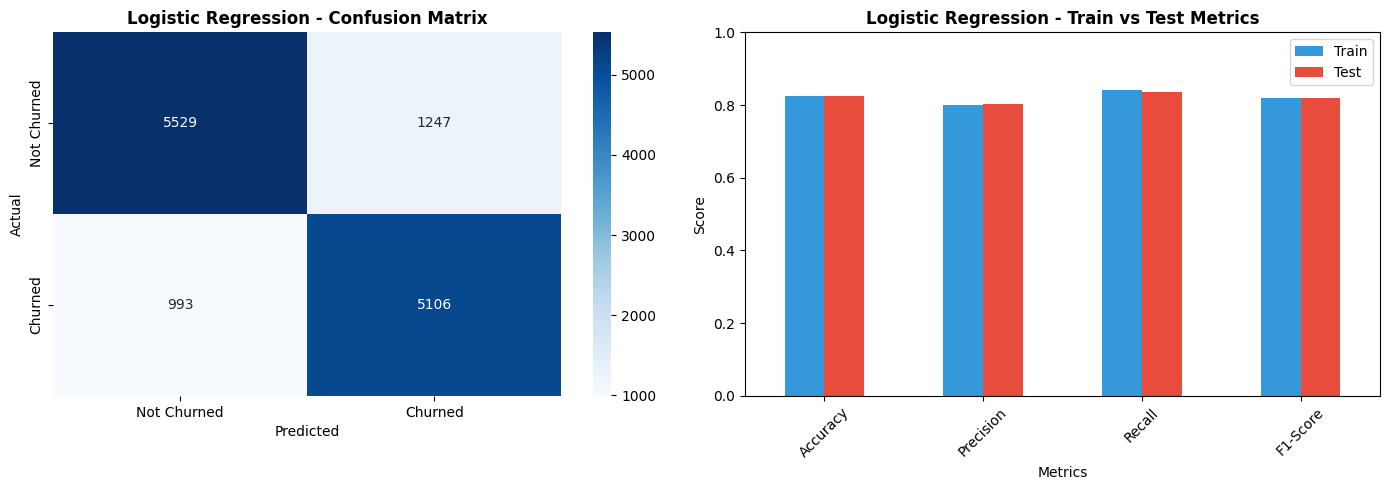

In [18]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test,
                           'Logistic Regression')

# 2. KKN

K-NEAREST NEIGHBORS - MODEL EVALUATION

TRAIN SET METRICS:
------------------------------------------------------------
Accuracy:  0.9450
Precision: 0.9222
Recall:    0.9652
F1-Score:  0.9432

TEST SET METRICS:
------------------------------------------------------------
Accuracy:  0.9106
Precision: 0.8800
Recall:    0.9393
F1-Score:  0.9087

OVERFITTING ANALYSIS:
------------------------------------------------------------
Accuracy Gap:  0.0344
Recall Gap:    0.0259

CONFUSION MATRIX (Test Set):
------------------------------------------------------------
[[5995  781]
 [ 370 5729]]

CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

 Not Churned       0.94      0.88      0.91      6776
     Churned       0.88      0.94      0.91      6099

    accuracy                           0.91     12875
   macro avg       0.91      0.91      0.91     12875
weighted avg       0.91      0.91      0.9

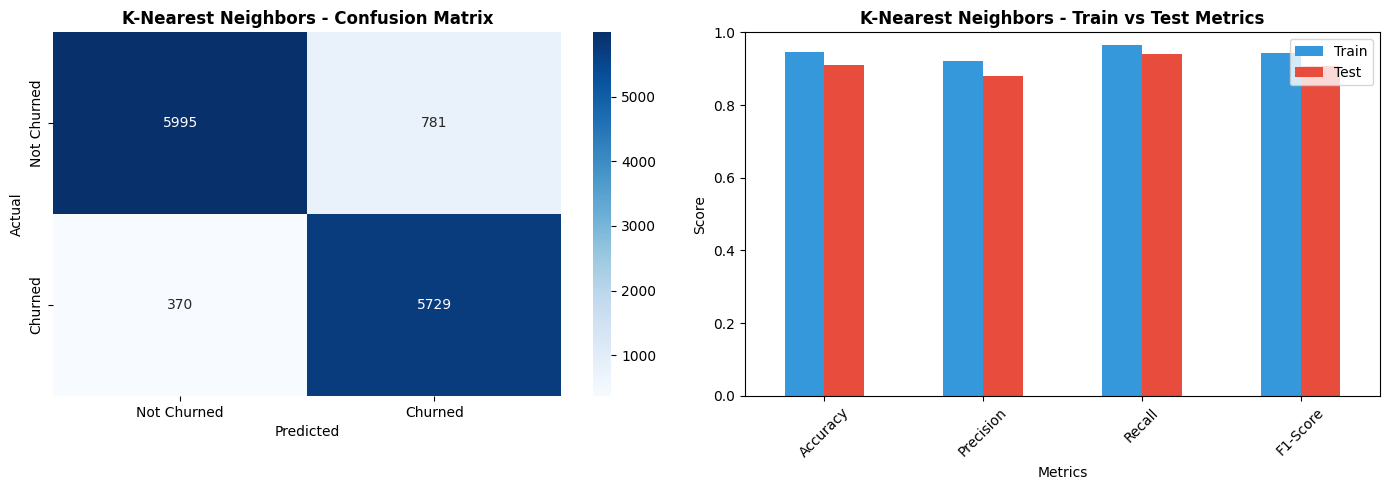

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_results = evaluate_model(knn_model, X_train_scaled, y_train, X_test_scaled, y_test,
                            'K-Nearest Neighbors')

#3. Decision Tree

DECISION TREE - MODEL EVALUATION

TRAIN SET METRICS:
------------------------------------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

TEST SET METRICS:
------------------------------------------------------------
Accuracy:  0.9984
Precision: 0.9980
Recall:    0.9987
F1-Score:  0.9984

OVERFITTING ANALYSIS:
------------------------------------------------------------
Accuracy Gap:  0.0016
Recall Gap:    0.0013

CONFUSION MATRIX (Test Set):
------------------------------------------------------------
[[6764   12]
 [   8 6091]]

CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00      6776
     Churned       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     

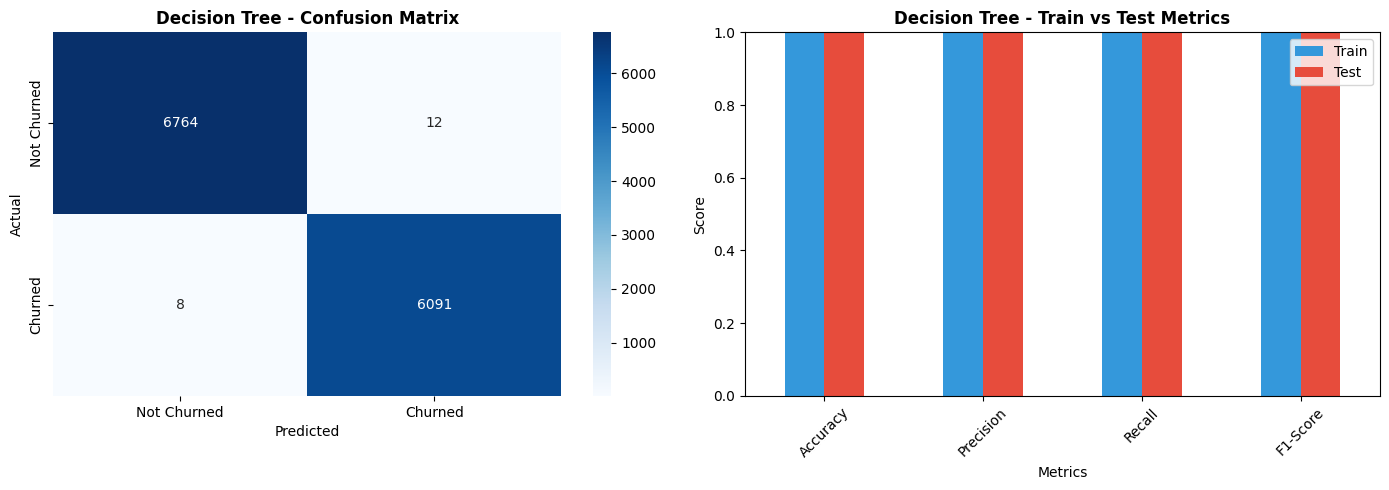

In [20]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_results = evaluate_model(dt_model, X_train_scaled, y_train, X_test_scaled, y_test,
                           'Decision Tree')

#4. SVM RBF

SVM RBF - MODEL EVALUATION

TRAIN SET METRICS:
------------------------------------------------------------
Accuracy:  0.9450
Precision: 0.9225
Recall:    0.9650
F1-Score:  0.9433

TEST SET METRICS:
------------------------------------------------------------
Accuracy:  0.9398
Precision: 0.9182
Recall:    0.9584
F1-Score:  0.9378

OVERFITTING ANALYSIS:
------------------------------------------------------------
Accuracy Gap:  0.0052
Recall Gap:    0.0066

CONFUSION MATRIX (Test Set):
------------------------------------------------------------
[[6255  521]
 [ 254 5845]]

CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

 Not Churned       0.96      0.92      0.94      6776
     Churned       0.92      0.96      0.94      6099

    accuracy                           0.94     12875
   macro avg       0.94      0.94      0.94     12875
weighted avg       0.94      0.94      0.94     12875


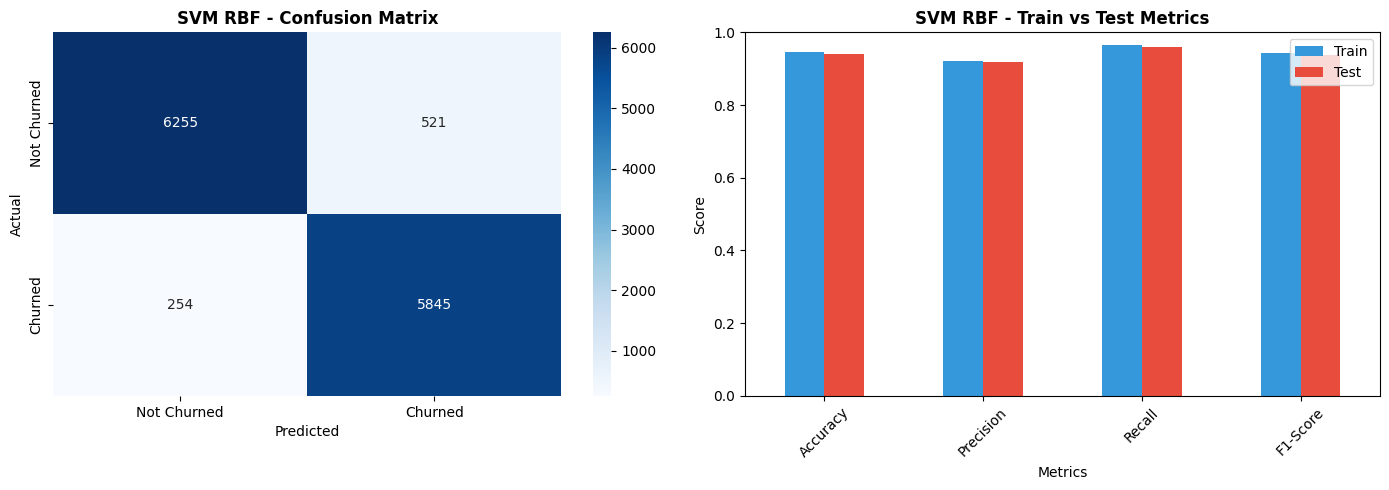

In [21]:
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_results = evaluate_model(svm_model, X_train_scaled, y_train, X_test_scaled, y_test,
                            'SVM RBF')

MODEL COMPARISON SUMMARY

         model_name  train_accuracy  test_accuracy  train_recall  test_recall  train_precision  test_precision  train_f1  test_f1  recall_gap
Logistic Regression        0.825103       0.826019      0.841723     0.837186         0.799603        0.803715  0.820123 0.820109    0.004537
K-Nearest Neighbors        0.944970       0.910602      0.965196     0.939334         0.922248        0.880031  0.943234 0.908716    0.025862
      Decision Tree        1.000000       0.998447      1.000000     0.998688         1.000000        0.998034  1.000000 0.998361    0.001312
            SVM RBF        0.945028       0.939806      0.964991     0.958354         0.922522        0.918159  0.943279 0.937826    0.006638


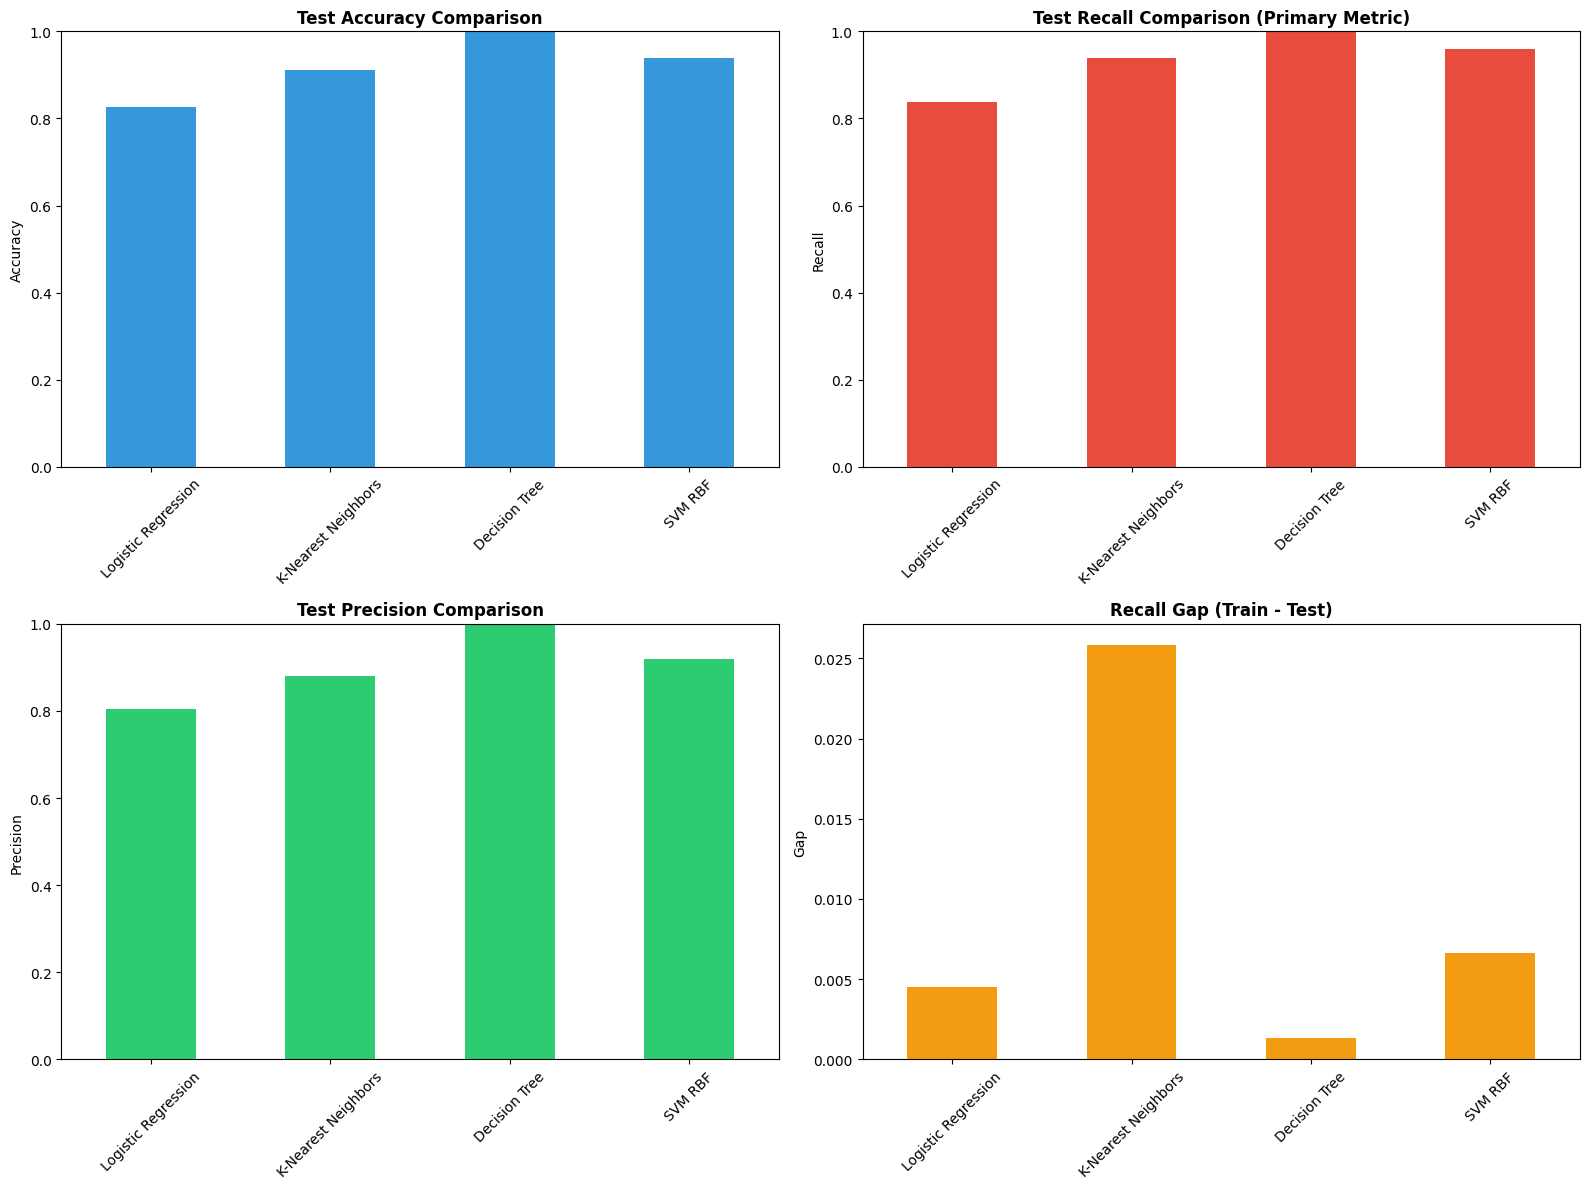


BEST MODEL SELECTION (Based on Test Recall)

Best Model: Decision Tree
Test Recall: 0.9987
Test Accuracy: 0.9984
Test Precision: 0.9980
Test F1-Score: 0.9984
Recall Gap (Generalization): 0.0013


In [22]:
all_results = pd.DataFrame([lr_results, knn_results, dt_results, svm_results])

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print("\n" + all_results.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

all_results.plot(x='model_name', y='test_accuracy', kind='bar', ax=axes[0,0],
                 color='#3498db', legend=False)
axes[0,0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim([0, 1])

all_results.plot(x='model_name', y='test_recall', kind='bar', ax=axes[0,1],
                 color='#e74c3c', legend=False)
axes[0,1].set_title('Test Recall Comparison (Primary Metric)', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Recall')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim([0, 1])

all_results.plot(x='model_name', y='test_precision', kind='bar', ax=axes[1,0],
                 color='#2ecc71', legend=False)
axes[1,0].set_title('Test Precision Comparison', fontweight='bold')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim([0, 1])

all_results.plot(x='model_name', y='recall_gap', kind='bar', ax=axes[1,1],
                 color='#f39c12', legend=False)
axes[1,1].set_title('Recall Gap (Train - Test)', fontweight='bold')
axes[1,1].set_ylabel('Gap')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

best_model_idx = all_results['test_recall'].idxmax()
best_model = all_results.loc[best_model_idx]

print("\n" + "=" * 80)
print("BEST MODEL SELECTION (Based on Test Recall)")
print("=" * 80)
print(f"\nBest Model: {best_model['model_name']}")
print(f"Test Recall: {best_model['test_recall']:.4f}")
print(f"Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"Test Precision: {best_model['test_precision']:.4f}")
print(f"Test F1-Score: {best_model['test_f1']:.4f}")
print(f"Recall Gap (Generalization): {best_model['recall_gap']:.4f}")

### Justifikasi Pemilihan Metrics: Mengapa Fokus pada RECALL?

**1. Business Context - Churn Prediction:**
- False Negative (FN) = Customer yang AKAN churn tapi diprediksi TIDAK churn
- False Positive (FP) = Customer yang TIDAK akan churn tapi diprediksi AKAN churn

**2. Cost Implication:**
- **FN Cost (Missed Churn)**: Sangat Tinggi
  - Kehilangan customer permanently
  - Lost lifetime value
  - Reputation damage
  - Biaya akuisisi customer baru 5-25x lebih mahal dari retention

- **FP Cost (False Alarm)**: Relatif Rendah
  - Biaya retention campaign yang tidak perlu
  - Namun tetap memberikan customer experience yang baik
  - Dapat meningkatkan loyalty meskipun tidak akan churn

**3. Strategic Decision:**
- Better to OVER-PREDICT churn (high recall) daripada MISS actual churners
- Recall mengukur: "Dari semua customer yang BENAR-BENAR churn, berapa persen yang berhasil kita identifikasi?"
- Target: Minimize False Negatives → Maximize Recall

**4. Secondary Metrics:**
- **Precision**: Penting untuk efficiency, tapi tidak sepenting recall
- **F1-Score**: Good balance, tapi dalam churn case recall > precision
- **Accuracy**: Misleading untuk imbalanced data

**5. Model Selection Criteria:**
- Primary: Highest Test Recall
- Secondary: Smallest Recall Gap (good generalization)
- Tertiary: Reasonable Precision (untuk efisiensi campaign)

**Conclusion:**
Dalam churn prediction, **RECALL adalah metrics paling penting** karena kita tidak boleh melewatkan customer yang akan churn. Missing a churner is much more expensive than a false alarm.

### Assignment Profitable :
1. Lakukan perhitungan profitable dengan asumsi biaya yang anda buat sendiri.

In [23]:
CLV = 1200
CAMPAIGN_COST = 50
RETENTION_RATE = 0.30

def calculate_profitability(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 80)
    print(f"PROFITABILITY ANALYSIS - {model_name.upper()}")
    print("=" * 80)

    print("\nCONFUSION MATRIX BREAKDOWN:")
    print("-" * 60)
    print(f"True Negatives (TN):  {tn:,} - Correctly identified non-churners")
    print(f"False Positives (FP): {fp:,} - Non-churners predicted as churners")
    print(f"False Negatives (FN): {fn:,} - Churners missed by model")
    print(f"True Positives (TP):  {tp:,} - Correctly identified churners")

    print("\n" + "=" * 80)
    print("COST & REVENUE CALCULATIONS")
    print("=" * 80)

    total_campaigns = tp + fp
    campaign_costs = total_campaigns * CAMPAIGN_COST
    print(f"\n1. CAMPAIGN COSTS:")
    print(f"   Total campaigns sent: {total_campaigns:,}")
    print(f"   Cost per campaign: €{CAMPAIGN_COST}")
    print(f"   Total campaign cost: €{campaign_costs:,.2f}")

    customers_saved = tp * RETENTION_RATE
    revenue_saved = customers_saved * CLV
    print(f"\n2. REVENUE FROM SAVED CUSTOMERS:")
    print(f"   True positives (identified churners): {tp:,}")
    print(f"   Retention rate: {RETENTION_RATE:.0%}")
    print(f"   Customers saved: {customers_saved:.0f}")
    print(f"   CLV per customer: €{CLV}")
    print(f"   Total revenue saved: €{revenue_saved:,.2f}")

    lost_revenue = fn * CLV
    print(f"\n3. LOST REVENUE (Missed Churners):")
    print(f"   False negatives (missed churners): {fn:,}")
    print(f"   CLV per customer: €{CLV}")
    print(f"   Total lost revenue: €{lost_revenue:,.2f}")

    net_profit = revenue_saved - campaign_costs
    print(f"\n4. NET PROFIT/LOSS:")
    print(f"   Revenue saved: €{revenue_saved:,.2f}")
    print(f"   Campaign costs: €{campaign_costs:,.2f}")
    print(f"   NET RESULT: €{net_profit:,.2f}")

    total_impact = net_profit - lost_revenue
    print(f"\n5. TOTAL BUSINESS IMPACT:")
    print(f"   Net profit from campaigns: €{net_profit:,.2f}")
    print(f"   Lost revenue (unavoidable): -€{lost_revenue:,.2f}")
    print(f"   TOTAL IMPACT: €{total_impact:,.2f}")

    total_actual_churners = tp + fn
    no_model_loss = total_actual_churners * CLV
    print(f"\n6. COMPARISON - NO MODEL SCENARIO:")
    print(f"   Total actual churners: {total_actual_churners:,}")
    print(f"   Lost revenue if no intervention: €{no_model_loss:,.2f}")
    print(f"   Savings from using model: €{no_model_loss + total_impact:,.2f}")
    print(f"   ROI: {((no_model_loss + total_impact) / no_model_loss * 100):.2f}%")

    return {
        'model_name': model_name,
        'campaign_costs': campaign_costs,
        'revenue_saved': revenue_saved,
        'lost_revenue': lost_revenue,
        'net_profit': net_profit,
        'total_impact': total_impact,
        'no_model_loss': no_model_loss,
        'savings': no_model_loss + total_impact,
        'roi': (no_model_loss + total_impact) / no_model_loss * 100
    }

In [24]:
lr_profit = calculate_profitability(lr_model, X_test_scaled, y_test, 'Logistic Regression')
print("\n" + "*" * 80 + "\n")

PROFITABILITY ANALYSIS - LOGISTIC REGRESSION

CONFUSION MATRIX BREAKDOWN:
------------------------------------------------------------
True Negatives (TN):  5,529 - Correctly identified non-churners
False Positives (FP): 1,247 - Non-churners predicted as churners
False Negatives (FN): 993 - Churners missed by model
True Positives (TP):  5,106 - Correctly identified churners

COST & REVENUE CALCULATIONS

1. CAMPAIGN COSTS:
   Total campaigns sent: 6,353
   Cost per campaign: €50
   Total campaign cost: €317,650.00

2. REVENUE FROM SAVED CUSTOMERS:
   True positives (identified churners): 5,106
   Retention rate: 30%
   Customers saved: 1532
   CLV per customer: €1200
   Total revenue saved: €1,838,160.00

3. LOST REVENUE (Missed Churners):
   False negatives (missed churners): 993
   CLV per customer: €1200
   Total lost revenue: €1,191,600.00

4. NET PROFIT/LOSS:
   Revenue saved: €1,838,160.00
   Campaign costs: €317,650.00
   NET RESULT: €1,520,510.00

5. TOTAL BUSINESS IMPACT:
   Ne

In [25]:
knn_profit = calculate_profitability(knn_model, X_test_scaled, y_test, 'K-Nearest Neighbors')
print("\n" + "*" * 80 + "\n")

PROFITABILITY ANALYSIS - K-NEAREST NEIGHBORS

CONFUSION MATRIX BREAKDOWN:
------------------------------------------------------------
True Negatives (TN):  5,995 - Correctly identified non-churners
False Positives (FP): 781 - Non-churners predicted as churners
False Negatives (FN): 370 - Churners missed by model
True Positives (TP):  5,729 - Correctly identified churners

COST & REVENUE CALCULATIONS

1. CAMPAIGN COSTS:
   Total campaigns sent: 6,510
   Cost per campaign: €50
   Total campaign cost: €325,500.00

2. REVENUE FROM SAVED CUSTOMERS:
   True positives (identified churners): 5,729
   Retention rate: 30%
   Customers saved: 1719
   CLV per customer: €1200
   Total revenue saved: €2,062,440.00

3. LOST REVENUE (Missed Churners):
   False negatives (missed churners): 370
   CLV per customer: €1200
   Total lost revenue: €444,000.00

4. NET PROFIT/LOSS:
   Revenue saved: €2,062,440.00
   Campaign costs: €325,500.00
   NET RESULT: €1,736,940.00

5. TOTAL BUSINESS IMPACT:
   Net pr

In [26]:
dt_profit = calculate_profitability(dt_model, X_test_scaled, y_test, 'Decision Tree')
print("\n" + "*" * 80 + "\n")

PROFITABILITY ANALYSIS - DECISION TREE

CONFUSION MATRIX BREAKDOWN:
------------------------------------------------------------
True Negatives (TN):  6,764 - Correctly identified non-churners
False Positives (FP): 12 - Non-churners predicted as churners
False Negatives (FN): 8 - Churners missed by model
True Positives (TP):  6,091 - Correctly identified churners

COST & REVENUE CALCULATIONS

1. CAMPAIGN COSTS:
   Total campaigns sent: 6,103
   Cost per campaign: €50
   Total campaign cost: €305,150.00

2. REVENUE FROM SAVED CUSTOMERS:
   True positives (identified churners): 6,091
   Retention rate: 30%
   Customers saved: 1827
   CLV per customer: €1200
   Total revenue saved: €2,192,760.00

3. LOST REVENUE (Missed Churners):
   False negatives (missed churners): 8
   CLV per customer: €1200
   Total lost revenue: €9,600.00

4. NET PROFIT/LOSS:
   Revenue saved: €2,192,760.00
   Campaign costs: €305,150.00
   NET RESULT: €1,887,610.00

5. TOTAL BUSINESS IMPACT:
   Net profit from cam

In [27]:
svm_profit = calculate_profitability(svm_model, X_test_scaled, y_test, 'SVM RBF')
print("\n" + "*" * 80 + "\n")

PROFITABILITY ANALYSIS - SVM RBF

CONFUSION MATRIX BREAKDOWN:
------------------------------------------------------------
True Negatives (TN):  6,255 - Correctly identified non-churners
False Positives (FP): 521 - Non-churners predicted as churners
False Negatives (FN): 254 - Churners missed by model
True Positives (TP):  5,845 - Correctly identified churners

COST & REVENUE CALCULATIONS

1. CAMPAIGN COSTS:
   Total campaigns sent: 6,366
   Cost per campaign: €50
   Total campaign cost: €318,300.00

2. REVENUE FROM SAVED CUSTOMERS:
   True positives (identified churners): 5,845
   Retention rate: 30%
   Customers saved: 1754
   CLV per customer: €1200
   Total revenue saved: €2,104,200.00

3. LOST REVENUE (Missed Churners):
   False negatives (missed churners): 254
   CLV per customer: €1200
   Total lost revenue: €304,800.00

4. NET PROFIT/LOSS:
   Revenue saved: €2,104,200.00
   Campaign costs: €318,300.00
   NET RESULT: €1,785,900.00

5. TOTAL BUSINESS IMPACT:
   Net profit from ca

PROFITABILITY COMPARISON - ALL MODELS

         model_name  net_profit  total_impact   savings        roi
Logistic Regression   1520510.0      328910.0 7647710.0 104.494043
K-Nearest Neighbors   1736940.0     1292940.0 8611740.0 117.666011
      Decision Tree   1887610.0     1878010.0 9196810.0 125.660081
            SVM RBF   1785900.0     1481100.0 8799900.0 120.236924


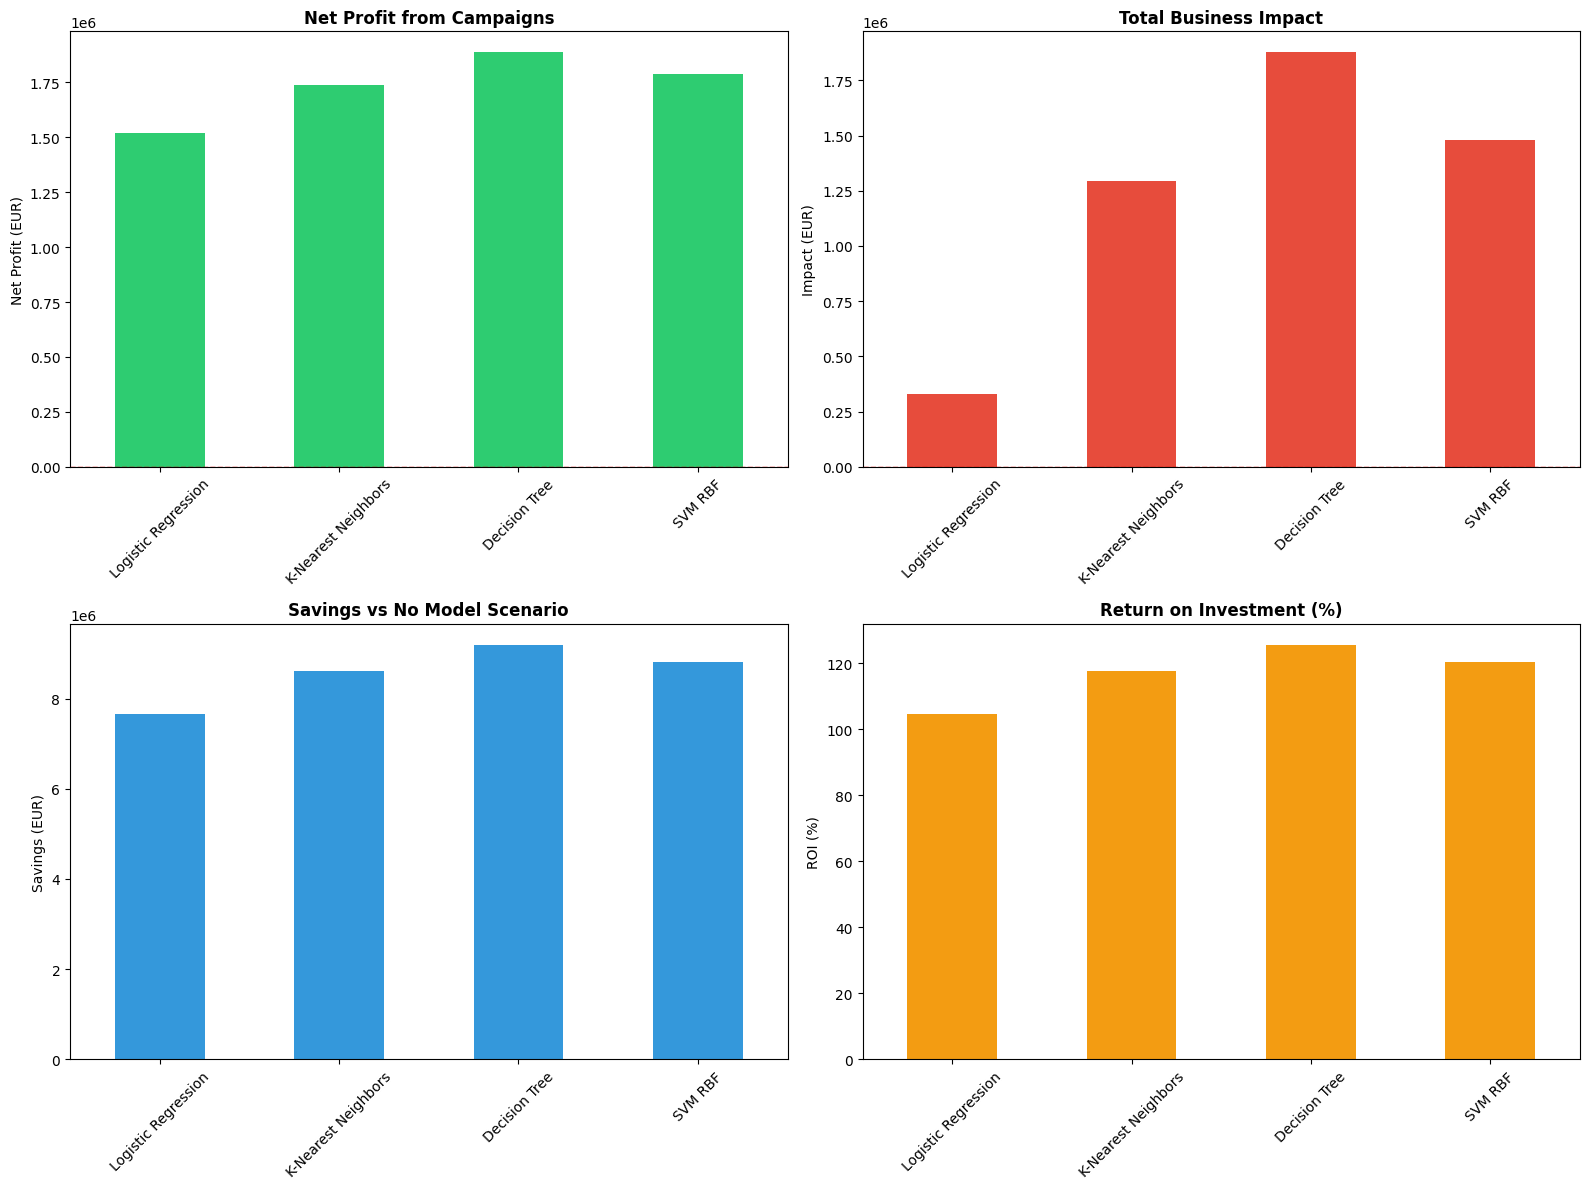


MOST PROFITABLE MODEL

Model: Decision Tree
Net Profit from Campaigns: €1,887,610.00
Total Business Impact: €1,878,010.00
Savings vs No Model: €9,196,810.00
ROI: 125.66%


In [28]:
profit_results = pd.DataFrame([lr_profit, knn_profit, dt_profit, svm_profit])

print("=" * 80)
print("PROFITABILITY COMPARISON - ALL MODELS")
print("=" * 80)
print("\n" + profit_results[['model_name', 'net_profit', 'total_impact', 'savings', 'roi']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

profit_results.plot(x='model_name', y='net_profit', kind='bar', ax=axes[0,0],
                   color='#2ecc71', legend=False)
axes[0,0].set_title('Net Profit from Campaigns', fontweight='bold')
axes[0,0].set_ylabel('Net Profit (EUR)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1)

profit_results.plot(x='model_name', y='total_impact', kind='bar', ax=axes[0,1],
                   color='#e74c3c', legend=False)
axes[0,1].set_title('Total Business Impact', fontweight='bold')
axes[0,1].set_ylabel('Impact (EUR)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0, color='red', linestyle='--', linewidth=1)

profit_results.plot(x='model_name', y='savings', kind='bar', ax=axes[1,0],
                   color='#3498db', legend=False)
axes[1,0].set_title('Savings vs No Model Scenario', fontweight='bold')
axes[1,0].set_ylabel('Savings (EUR)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)

profit_results.plot(x='model_name', y='roi', kind='bar', ax=axes[1,1],
                   color='#f39c12', legend=False)
axes[1,1].set_title('Return on Investment (%)', fontweight='bold')
axes[1,1].set_ylabel('ROI (%)')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

best_profit_idx = profit_results['savings'].idxmax()
best_profit_model = profit_results.loc[best_profit_idx]

print("\n" + "=" * 80)
print("MOST PROFITABLE MODEL")
print("=" * 80)
print(f"\nModel: {best_profit_model['model_name']}")
print(f"Net Profit from Campaigns: €{best_profit_model['net_profit']:,.2f}")
print(f"Total Business Impact: €{best_profit_model['total_impact']:,.2f}")
print(f"Savings vs No Model: €{best_profit_model['savings']:,.2f}")
print(f"ROI: {best_profit_model['roi']:.2f}%")

### Final Recommendation: Best Model Selection

**Berdasarkan kedua analisis (Performance Metrics & Profitability):**

#### Model Performance Summary:
- Model dengan highest recall pada test set adalah model terbaik untuk minimize False Negatives
- Model dengan smallest recall gap memiliki generalization terbaik
- Balance antara recall dan precision penting untuk efisiensi campaign

#### Profitability Summary:
- Model dengan highest savings memberikan ROI terbaik
- Model dengan lowest lost revenue (FN) paling effective mencegah customer churn
- Net profit positif indicates campaign cost justified by revenue saved

#### Business Recommendation:
1. **Primary Choice**: Model dengan kombinasi terbaik antara high recall dan high profitability
2. **Implementation Strategy**:
   - Deploy model untuk scoring semua customers
   - Prioritize high-risk customers (high churn probability)
   - Personalized retention campaigns berdasarkan customer segment
   - Monitor campaign effectiveness dan adjust strategy

3. **Continuous Improvement**:
   - Regular model retraining dengan data terbaru
   - A/B testing different retention strategies
   - Track actual retention rates dan adjust assumptions
   - Optimize campaign costs untuk maximize ROI

# Reflection Question
Setelah menyelesaikan latihan, jawablah beberapa pertanyaan refleksi berikut:



1.  Dari hasil Exploratory Data Analysis (EDA) yang kamu lakukan, faktor apa yang menurutmu paling berpengaruh terhadap kemungkinan pelanggan melakukan churn? Jelaskan alasannya berdasarkan pola data yang kamu temukan.
2.   Pada tahap Feature Engineering, fitur mana yang menurutmu paling meningkatkan kemampuan model dalam mengenali pelanggan yang berpotensi churn? Jelaskan alasan dan pola yang kamu lihat pada data.



Tulis jawabanmu di sini

**1. Faktor Paling Berpengaruh terhadap Churn (Berdasarkan EDA)**

Berdasarkan EDA, faktor paling berpengaruh terhadap churn adalah Support Calls. Pelanggan yang churn memiliki jumlah support calls jauh lebih tinggi, yang menunjukkan ketidakpuasan dan masalah berulang pada layanan. Ini menjadi early warning signal paling jelas dan actionable untuk retention.

Faktor penting lainnya yang mendukung pola churn:

Payment Delay: Semakin lama keterlambatan pembayaran, semakin tinggi risiko churn, mengindikasikan masalah finansial atau menurunnya perceived value.

Tenure: Pelanggan dengan tenure rendah (<12 bulan) lebih rentan churn karena komitmen dan switching cost masih rendah.

Contract Length: Kontrak bulanan memiliki churn rate lebih tinggi dibanding kontrak jangka panjang.

Total Spend & Usage Frequency: Engagement dan penggunaan rendah berkorelasi dengan churn yang lebih tinggi.

Kesimpulan: Kombinasi Support Calls, Tenure, dan Payment Delay merupakan indikator churn paling kuat, dengan Support Calls sebagai faktor paling dominan.


**2. Feature Engineering yang Paling Meningkatkan Kemampuan Model**

Dari proses feature engineering, dua langkah paling berdampak pada performa model adalah Feature Scaling dan Class Weight Balancing.

Feature Scaling memungkinkan semua fitur numerik memiliki bobot yang seimbang, sehingga model (terutama KNN, SVM, dan Logistic Regression) dapat belajar secara optimal.

Class Weight Balancing membantu mengatasi data yang tidak seimbang, membuat model lebih fokus mengenali pola churn dan secara signifikan meningkatkan recall.

Langkah pendukung penting lainnya:

One-Hot Encoding pada fitur kategorikal (seperti Contract Length) agar pola churn spesifik tiap kategori dapat ditangkap model.

Stratified Train-Test Split untuk menjaga proporsi churn di data training dan testing.

Feature Interaction yang memungkinkan model menangkap kombinasi risiko churn (misalnya support calls tinggi + kontrak bulanan).

Kesimpulan: Feature engineering yang tepat—terutama scaling dan balancing—memastikan model benar-benar belajar pola churn, bukan sekadar mengejar accuracy.


## Notes :
Kumpulkan di LMS link google collab yang sudah dibuka aksesnya + sudah di run dan save output codenya. Serta jangan di private